# TRM Sudoku Experiment Notebook

Self-contained notebook for running TRM experiments on Google Colab (CUDA GPU).

**Workflow:** Adjust the config cell, run all, download the results JSON + plots.

In [1]:
#@title 🔧 Z3 Symbolic Logit Pruning (Tensorized)
import torch

def prune_illegal_logits_z3(y_hat: torch.Tensor, hard_preds: torch.Tensor, grid_size: int = 4) -> torch.Tensor:
    """
    Prune illegal logits based on 4x4 Sudoku constraints (rows, cols, 2x2 subgrids).

    Args:
        y_hat: [B, seq_len, N] raw logits
        hard_preds: [B, seq_len] current digit predictions (1..N)
        grid_size: 4 for mini-sudoku

    Returns:
        y_hat with illegal moves masked to -1e9
    """
    B, seq_len, N = y_hat.shape
    sub_size = 2  # 4x4 sudoku has 2x2 subgrids

    # Reshape predictions into 2D grid: [B, grid_size, grid_size]
    grid = hard_preds.reshape(B, grid_size, grid_size)

    # One-hot encode digits 1..N into [B, grid_size, grid_size, N]
    # Use int8 instead of bool so arithmetic (sum/subtract) works
    digits_onehot = torch.zeros(B, grid_size, grid_size, N, device=y_hat.device, dtype=torch.int8)
    for d in range(1, N + 1):
        digits_onehot[..., d - 1] = (grid == d)

    # Build mask: [B, grid_size, grid_size, N] — True means "digit already used, illegal"
    mask = torch.zeros(B, grid_size, grid_size, N, device=y_hat.device, dtype=torch.bool)

    for r in range(grid_size):
        for c in range(grid_size):
            # Row constraint: any digit already in this row (excluding self)
            row_used = digits_onehot[:, r, :, :].sum(dim=1)  # [B, N]
            row_used = row_used - digits_onehot[:, r, c, :]  # exclude self
            mask[:, r, c, :] |= (row_used > 0)

            # Column constraint: any digit already in this column (excluding self)
            col_used = digits_onehot[:, :, c, :].sum(dim=1)  # [B, N]
            col_used = col_used - digits_onehot[:, r, c, :]  # exclude self
            mask[:, r, c, :] |= (col_used > 0)

            # Subgrid constraint
            br = sub_size * (r // sub_size)
            bc = sub_size * (c // sub_size)
            box_used = digits_onehot[:, br:br+sub_size, bc:bc+sub_size, :].sum(dim=(1, 2))  # [B, N]
            box_used = box_used - digits_onehot[:, r, c, :]  # exclude self
            mask[:, r, c, :] |= (box_used > 0)

    # Flatten spatial dims back to seq_len: [B, seq_len, N]
    mask = mask.reshape(B, seq_len, N)

    # Apply mask
    y_hat = y_hat.masked_fill(mask, -1e9)
    return y_hat


# Mock the symbolic module so the Model Architecture cell's import resolves.
# Use types.ModuleType to avoid the descriptor protocol turning the function
# into a bound method (which would shift all positional args by one).
import sys, types
_sym = types.ModuleType('symbolic')
_z3 = types.ModuleType('symbolic.z3_sudoku')
_z3.prune_illegal_logits_z3 = prune_illegal_logits_z3
_sym.z3_sudoku = _z3
sys.modules['symbolic'] = _sym
sys.modules['symbolic.z3_sudoku'] = _z3

In [2]:
#@title ⚙️ Experiment Config { run: "auto" }
#@markdown ---
#@markdown ### Architecture
grid_size = 4 #@param [4, 9] {type:"raw"}
dim = 128 #@param {type:"integer"}
n_layers = 2 #@param {type:"integer"}
n_heads = 8 #@param {type:"integer"}
n_recursions = 4 #@param {type:"integer"}
n_cycles = 3 #@param {type:"integer"}
n_supervision = 7 #@param {type:"integer"}

#@markdown ### Symbolic Integration
use_z3_pruning = True #@param {type:"boolean"}

#@markdown ### Training
batch_size = 64 #@param {type:"integer"}
lr = 3e-4 #@param {type:"number"}
weight_decay = 0.1 #@param {type:"number"}
num_epochs = 20 #@param {type:"integer"}
max_steps = 100000 #@param {type:"integer"}
warmup_steps = 1000 #@param {type:"integer"}

#@markdown ### Data
num_train = 5000 #@param {type:"integer"}
num_val = 1000 #@param {type:"integer"}
seed = 42 #@param {type:"integer"}

#@markdown ### Notes
run_notes = "" #@param {type:"string"}

# --- Derived ---
import os, time, pathlib

# Grid-derived constants
sub_size = {4: 2, 9: 3}[grid_size]
n_digits = grid_size
n_cells = grid_size * grid_size
min_givens = {4: 4, 9: 17}[grid_size]
max_givens = {4: 10, 9: 35}[grid_size]

task = "sudoku"

# Resolve results dir to repo-level results/ regardless of CWD
_NOTEBOOK_DIR = pathlib.Path(os.path.abspath('')).resolve()
_REPO_ROOT = _NOTEBOOK_DIR.parent if _NOTEBOOK_DIR.name == 'notebooks' else _NOTEBOOK_DIR
RESULTS_DIR = str(_REPO_ROOT / 'results')
CHECKPOINT_DIR = str(_REPO_ROOT / f'checkpoints_{task}')
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
run_name = f'{task}_{time.strftime("%Y%m%d_%H%M%S")}'

cfg = dict(
    dim=dim, n_layers=n_layers, n_heads=n_heads,
    n_recursions=n_recursions, n_cycles=n_cycles, n_supervision=n_supervision,
    batch_size=batch_size, lr=lr, weight_decay=weight_decay,
    num_epochs=num_epochs, max_steps=max_steps, warmup_steps=warmup_steps,
    num_train=num_train, num_val=num_val, seed=seed,
    task=task,
    grid_size=grid_size, sub_size=sub_size, n_digits=n_digits,
    min_givens=min_givens, max_givens=max_givens,
    use_z3_pruning=use_z3_pruning,
)

print(f"Run name: {run_name}")
print(f"Results dir: {RESULTS_DIR}/")
print(f"Checkpoint dir: {CHECKPOINT_DIR}/")
print(f"\nExperiment config:")
for k, v in sorted(cfg.items()):
    print(f"  {k}: {v}")

Run name: sudoku_20260404_185547
Results dir: /content/results/
Checkpoint dir: /content/checkpoints_sudoku/

Experiment config:
  batch_size: 64
  dim: 128
  grid_size: 4
  lr: 0.0003
  max_givens: 10
  max_steps: 100000
  min_givens: 4
  n_cycles: 3
  n_digits: 4
  n_heads: 8
  n_layers: 2
  n_recursions: 4
  n_supervision: 7
  num_epochs: 20
  num_train: 5000
  num_val: 1000
  seed: 42
  sub_size: 2
  task: sudoku
  use_z3_pruning: True
  warmup_steps: 1000
  weight_decay: 0.1


In [3]:
#@title 💻 Device Setup
import torch
import json
import numpy as np
import ipywidgets as widgets # type: ignore

def get_device():
    if torch.cuda.is_available():
        return 'cuda'
    if hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'

device = get_device()
cfg['device'] = device

print(f"PyTorch {torch.__version__}")
print(f"Device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch 2.10.0+cu128
Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [4]:
#@title 🧩 Sudoku Data Generation

from torch.utils.data import Dataset
from typing import Tuple, Optional, List, Dict

# --- Puzzle generation (parameterized by grid_size) ---

def _fill_grid(grid, N, S, rng):
    """Backtracking fill for NxN sudoku with SxS subgrids."""
    for r in range(N):
        for c in range(N):
            if grid[r, c] == 0:
                nums = list(range(1, N + 1))
                rng.shuffle(nums)
                for n in nums:
                    if _is_valid_placement(grid, r, c, n, N, S):
                        grid[r, c] = n
                        if _fill_grid(grid, N, S, rng):
                            return True
                        grid[r, c] = 0
                return False
    return True

def _is_valid_placement(grid, row, col, num, N, S):
    if num in grid[row]: return False
    if num in grid[:, col]: return False
    br, bc = S * (row // S), S * (col // S)
    if num in grid[br:br+S, bc:bc+S]: return False
    return True

def generate_puzzle(num_givens, N, S, rng=None):
    if rng is None: rng = np.random.RandomState()
    grid = np.zeros((N, N), dtype=np.int64)
    _fill_grid(grid, N, S, rng)
    solution = grid.copy()
    num_remove = N * N - num_givens
    indices = list(range(N * N))
    rng.shuffle(indices)
    puzzle = solution.copy()
    for idx in indices[:num_remove]:
        puzzle[idx // N, idx % N] = 0
    return puzzle, solution

def _augment_sudoku(puzzle, solution, N, rng):
    perm = np.arange(N + 1)
    perm[1:] = rng.permutation(np.arange(1, N + 1))
    return perm[puzzle], perm[solution]

class SudokuDataset(Dataset):
    def __init__(self, num_samples, N, S, min_givens, max_givens, seed=42, augment=True):
        self.num_samples = num_samples
        self.N = N
        self.S = S
        self.augment = augment
        self.rng = np.random.RandomState(seed)
        self.puzzles, self.solutions = [], []
        for _ in range(num_samples):
            givens = self.rng.randint(min_givens, max_givens + 1)
            puzzle, solution = generate_puzzle(givens, N, S, self.rng)
            self.puzzles.append(puzzle.flatten())
            self.solutions.append(solution.flatten())

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        puzzle, solution = self.puzzles[idx].copy(), self.solutions[idx].copy()
        if self.augment:
            puzzle, solution = _augment_sudoku(
                puzzle.reshape(self.N, self.N),
                solution.reshape(self.N, self.N),
                self.N, np.random)
            puzzle, solution = puzzle.flatten(), solution.flatten()
        return torch.tensor(puzzle, dtype=torch.long), torch.tensor(solution, dtype=torch.long)

print(f"Generating {grid_size}x{grid_size} Sudoku datasets...")
train_ds = SudokuDataset(num_train, grid_size, sub_size, min_givens, max_givens, seed=seed, augment=True)
val_ds   = SudokuDataset(num_val, grid_size, sub_size, min_givens, max_givens, seed=seed+10000, augment=False)
print(f"  train: {len(train_ds)}   val: {len(val_ds)}")

Generating 4x4 Sudoku datasets...
  train: 5000   val: 1000


In [5]:
#@title 🏛️ Model Architecture

import torch.nn as nn
import torch.nn.functional as F
import math
import sys, pathlib

# --- Z3 symbolic pruning (optional) ---
try:
    # Add repo root to path for symbolic module import
    _repo = pathlib.Path(os.path.abspath("")).resolve()
    if _repo.name == "notebooks": _repo = _repo.parent
    if str(_repo) not in sys.path: sys.path.insert(0, str(_repo))
    from symbolic.z3_sudoku import prune_illegal_logits_z3
    _Z3_AVAILABLE = True
    print("Z3 symbolic pruning: available")
except ImportError:
    _Z3_AVAILABLE = False
    print("Z3 symbolic pruning: not available (z3-solver not installed)")

# --- Building blocks ---

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x * torch.rsqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps) * self.weight

class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=2048):
        super().__init__()
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        self._cache_len = 0
        self._cos_cache = self._sin_cache = None
    def forward(self, seq_len):
        if seq_len != self._cache_len:
            t = torch.arange(seq_len, device=self.inv_freq.device).type_as(self.inv_freq)
            freqs = t.unsqueeze(1) * self.inv_freq.unsqueeze(0)
            emb = torch.cat((freqs, freqs), dim=-1)
            self._cos_cache, self._sin_cache = emb.cos(), emb.sin()
            self._cache_len = seq_len
        return self._cos_cache, self._sin_cache

def apply_rotary_pos_emb(q, k, cos, sin):
    def rotate_half(x):
        x1, x2 = x[..., :x.shape[-1]//2], x[..., x.shape[-1]//2:]
        return torch.cat((-x2, x1), dim=-1)
    return (q*cos)+(rotate_half(q)*sin), (k*cos)+(rotate_half(k)*sin)

class SwiGLU(nn.Module):
    def __init__(self, dim, hidden_dim):
        super().__init__()
        self.w1 = nn.Linear(dim, hidden_dim, bias=False)
        self.w2 = nn.Linear(hidden_dim, dim, bias=False)
        self.w3 = nn.Linear(dim, hidden_dim, bias=False)
    def forward(self, x):
        return self.w2(F.silu(self.w1(x)) * self.w3(x))

class SelfAttention(nn.Module):
    def __init__(self, dim, n_heads=8):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dim // n_heads
        assert dim % n_heads == 0
        self.qkv = nn.Linear(dim, 3*dim, bias=False)
        self.proj = nn.Linear(dim, dim, bias=False)
        self.rotary = RotaryEmbedding(self.head_dim)
    def forward(self, x):
        B, L, D = x.shape
        qkv = self.qkv(x).reshape(B, L, 3, self.n_heads, self.head_dim).permute(2,0,3,1,4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        cos, sin = self.rotary(L)
        cos, sin = cos[None, None], sin[None, None]
        q, k = apply_rotary_pos_emb(q, k, cos, sin)
        out = F.scaled_dot_product_attention(q, k, v)
        return self.proj(out.transpose(1,2).contiguous().reshape(B, L, D))

class TransformerLayer(nn.Module):
    def __init__(self, dim, n_heads=8, mlp_ratio=4):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.mixer = SelfAttention(dim, n_heads)
        self.mlp = SwiGLU(dim, int(dim * mlp_ratio))
    def forward(self, x):
        x = x + self.mixer(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

# --- Sudoku Task Head ---

class SudokuHead(nn.Module):
    def __init__(self, dim, N=9):
        super().__init__()
        self.dim = dim
        self.N = N
        self.embedding = nn.Embedding(N + 1, dim)       # 0..N
        self.row_embed = nn.Embedding(N, dim)
        self.col_embed = nn.Embedding(N, dim)
        self.output = nn.Linear(dim, N, bias=False)      # N classes (digits 1..N)
        self.register_buffer("_row_idx", torch.arange(N).repeat_interleave(N))
        self.register_buffer("_col_idx", torch.arange(N).repeat(N))

    def encode(self, x_input):
        x = self.embedding(x_input)
        x = x + self.row_embed(self._row_idx)[None] + self.col_embed(self._col_idx)[None]
        return x

    def decode(self, hidden):
        return self.output(hidden)

    def compute_loss(self, logits, targets, x_input=None):
        class_targets = targets - 1
        if x_input is not None:
            class_targets = class_targets.clone()
            class_targets[x_input != 0] = -100
        return F.cross_entropy(logits.transpose(1,2), class_targets, ignore_index=-100)

    def check_correct(self, logits, targets, x_input=None):
        pred = logits.argmax(dim=-1) + 1
        if x_input is not None:
            mask = (x_input == 0)
            return ((pred == targets) | ~mask).all(dim=-1).float()
        return (pred == targets).all(dim=-1).float()

# --- TRM Core ---

class TinyRecursiveModel(nn.Module):
    def __init__(self, task_head, dim=128, n_layers=2, n_heads=8,
                 n_recursions=8, n_cycles=3, n_supervision=14,
                 use_z3_pruning=False):
        super().__init__()
        self.dim = dim
        self.n_recursions = n_recursions
        self.n_cycles = n_cycles
        self.n_supervision = n_supervision
        self.task_head = task_head
        self.use_z3_pruning = use_z3_pruning and _Z3_AVAILABLE
        self.y_init = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.z_init = nn.Parameter(torch.randn(1, 1, dim) * 0.02)
        self.layers = nn.ModuleList([TransformerLayer(dim, n_heads) for _ in range(n_layers)])
        self.output_norm = RMSNorm(dim)
        self.q_head = nn.Linear(dim, 1, bias=False)

    def forward_network(self, x):
        for layer in self.layers: x = layer(x)
        return x

    def latent_recursion(self, x, y, z):
        xy = x + y
        for _ in range(self.n_recursions):
            z = self.forward_network(xy + z)
        y = self.forward_network(y + z)
        return y, z

    def deep_recursion(self, x, y, z, with_gradients=False, x_input=None):
        if not with_gradients and self.n_cycles > 1:
            with torch.no_grad():
                for _ in range(self.n_cycles - 1):
                    y, z = self.latent_recursion(x, y, z)
        y, z = self.latent_recursion(x, y, z)
        y_norm = self.output_norm(y)
        y_hat = self.task_head.decode(y_norm)

        # --- Z3 Logit Pruning (inference only) ---
        # Applied only when not training (with_gradients=False) to avoid:
        # 1. Masking correct answers with bad early predictions → loss explosion
        # 2. no_grad detaching y_hat from the computation graph → zero gradients
        if self.use_z3_pruning and x_input is not None:
            with torch.no_grad():
                hard_preds = y_hat.argmax(dim=-1) + 1
                hard_preds[x_input != 0] = x_input[x_input != 0]
                y_hat = prune_illegal_logits_z3(y_hat, hard_preds)

        q_hat = torch.sigmoid(self.q_head(y_norm.mean(dim=1)))
        return (y, z), y_hat, q_hat

    def forward(self, x_input, y_true=None, training=True, return_all_steps=False):
        B = x_input.shape[0]
        x = self.task_head.encode(x_input)
        seq_len = x.shape[1]
        y = self.y_init.expand(B, seq_len, -1)
        z = self.z_init.expand(B, seq_len, -1)

        if training:
            losses, predictions, halts = [], [], []
            for _ in range(self.n_supervision):
                (y, z), y_hat, q_hat = self.deep_recursion(x, y, z, with_gradients=True, x_input=x_input)
                y, z = y.detach(), z.detach()
                predictions.append(y_hat)
                halts.append(q_hat)
                if y_true is not None:
                    pred_loss = self.task_head.compute_loss(y_hat, y_true, x_input)
                    is_correct = self.task_head.check_correct(y_hat, y_true, x_input)
                    halt_loss = F.binary_cross_entropy(q_hat.squeeze(-1), is_correct)
                    losses.append(pred_loss + 0.5 * halt_loss)
            return losses, predictions, halts
        else:
            all_preds = []
            for _ in range(self.n_supervision):
                (y, z), y_hat, q_hat = self.deep_recursion(x, y, z, with_gradients=False, x_input=x_input)
                y, z = y.detach(), z.detach()
                all_preds.append(y_hat)
            return (y_hat, all_preds) if return_all_steps else y_hat

    @torch.no_grad()
    def diagnostic_forward(self, x_input):
        self.eval()
        B = x_input.shape[0]
        x = self.task_head.encode(x_input)
        seq_len = x.shape[1]
        y = self.y_init.expand(B, seq_len, -1)
        z = self.z_init.expand(B, seq_len, -1)
        z_norms, y_norms, z_cosines = [], [], []
        y_heatmaps, halt_probs, predictions = [], [], []
        prev_z = None
        for _ in range(self.n_supervision):
            (y, z), y_hat, q_hat = self.deep_recursion(x, y, z, with_gradients=False, x_input=x_input)
            y, z = y.detach(), z.detach()
            z_norms.append(z.norm(dim=-1).mean().item())
            y_norms.append(y.norm(dim=-1).mean().item())
            if prev_z is not None:
                cos = F.cosine_similarity(prev_z.reshape(B,-1), z.reshape(B,-1), dim=-1).mean().item()
                z_cosines.append(cos)
            prev_z = z.clone()
            y_heatmaps.append(y.abs().mean(dim=(0,2)).cpu().numpy())
            halt_probs.append(q_hat.mean().item())
            predictions.append(y_hat)
        return dict(z_norms=z_norms, y_norms=y_norms, z_cosines=z_cosines,
                    y_heatmaps=y_heatmaps, halt_probs=halt_probs, predictions=predictions)

# --- Create model ---
task_head = SudokuHead(dim, N=grid_size)
model = TinyRecursiveModel(
    task_head, dim=dim, n_layers=n_layers, n_heads=n_heads,
    n_recursions=n_recursions, n_cycles=n_cycles, n_supervision=n_supervision,
    use_z3_pruning=use_z3_pruning,
).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model on {device.upper()} — {n_params:,} params")

Z3 symbolic pruning: available
Model on CUDA — 527,488 params


In [6]:
#@title 🏋️ Training Loop

from torch.optim import AdamW
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm

# --- EMA ---
class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {n: p.data.clone() for n, p in model.named_parameters() if p.requires_grad}
        self.backup = {}
    def update(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.shadow[n] = self.decay * self.shadow[n] + (1-self.decay) * p.data
    def apply_shadow(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                self.backup[n] = p.data.clone()
                p.data = self.shadow[n]
    def restore(self):
        for n, p in self.model.named_parameters():
            if p.requires_grad:
                p.data = self.backup[n]
        self.backup = {}

# --- Data Loaders ---
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                        num_workers=2, pin_memory=True)

# --- Optimizer ---
optimizer = AdamW(model.parameters(), lr=lr, betas=(0.9, 0.95), weight_decay=weight_decay)
ema = EMA(model)

# --- Checkpoint helpers ---
def save_checkpoint(filename):
    path = os.path.join(CHECKPOINT_DIR, filename)
    ckpt = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'step': step,
        'best_val_acc': best_val_acc,
        'ema_shadow': ema.shadow,
        'config': cfg,
    }
    torch.save(ckpt, path)
    print(f"  Saved: {path}")

# --- Training ---
step = 0
best_val_acc = 0.0
epoch_history = {'loss': [], 'accuracy': [], 'val_accuracy': []}

def get_lr():
    if step < warmup_steps:
        return lr * step / max(warmup_steps, 1)
    return lr

print(f"Training: {num_epochs} epochs, device={device}")
t_start = time.time()

for epoch in range(num_epochs):
    model.train()
    metrics = {'loss': [], 'accuracy': []}
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')

    for batch in pbar:
        x_input, y_true = [t.to(device) for t in batch]
        losses_list, predictions, halts = model(x_input, y_true, training=True)
        loss = torch.stack(losses_list).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # LR warmup
        for pg in optimizer.param_groups:
            pg['lr'] = get_lr()

        ema.update()

        acc = 0.0
        if step % 10 == 0:
            with torch.no_grad():
                acc = model.task_head.check_correct(predictions[-1], y_true, x_input).mean().item()

        step += 1
        metrics['loss'].append(loss.item())
        metrics['accuracy'].append(acc)
        pbar.set_postfix(loss=f"{loss.item():.4f}", acc=f"{acc:.3f}", lr=f"{get_lr():.2e}")

        if step >= max_steps:
            break

    avg_loss = sum(metrics['loss']) / len(metrics['loss'])
    avg_acc = sum(metrics['accuracy']) / len(metrics['accuracy'])
    epoch_history['loss'].append(avg_loss)
    epoch_history['accuracy'].append(avg_acc)

    # --- Validation ---
    model.eval()
    ema.apply_shadow()
    total_correct = total = 0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc='Val', leave=False):
            x_input, y_true = [t.to(device) for t in batch]
            y_hat = model(x_input, training=False)
            total_correct += model.task_head.check_correct(y_hat, y_true, x_input).sum().item()
            total += x_input.size(0)
    val_acc = total_correct / max(total, 1)
    ema.restore()
    epoch_history['val_accuracy'].append(val_acc)

    print(f"Epoch {epoch+1} — loss: {avg_loss:.4f}  acc: {avg_acc:.4f}  val_acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint('best_model.pt')

    if (epoch + 1) % 10 == 0:
        save_checkpoint(f'checkpoint_epoch_{epoch+1}.pt')

    if step >= max_steps:
        print(f"Reached max steps ({max_steps})")
        break

save_checkpoint('final_model.pt')
train_time = time.time() - t_start
print(f"\nTraining complete: {step} steps in {train_time:.0f}s")

Training: 20 epochs, device=cuda


Epoch 1/20:   0%|          | 0/79 [00:00<?, ?it/s]

Val:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 1 — loss: 226849520.2025  acc: 0.0022  val_acc: 0.0140
  Saved: /content/checkpoints_sudoku/best_model.pt


Epoch 2/20:   0%|          | 0/79 [00:00<?, ?it/s]

...

Val:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 19 — loss: 164859106.7342  acc: 0.0004  val_acc: 0.0020


Epoch 20/20:   0%|          | 0/79 [00:00<?, ?it/s]

Val:   0%|          | 0/16 [00:00<?, ?it/s]

Epoch 20 — loss: 163007854.3797  acc: 0.0004  val_acc: 0.0010
  Saved: /content/checkpoints_sudoku/checkpoint_epoch_20.pt
  Saved: /content/checkpoints_sudoku/final_model.pt

Training complete: 1580 steps in 538s


In [7]:
#@title 📊 Evaluation + Diagnostics

from collections import defaultdict

# --- Apply EMA for eval ---
ema.apply_shadow()
model.eval()

# --- Per-step accuracy ---
print("Per-step accuracy:")
step_correct = defaultdict(int)
step_total = defaultdict(int)
with torch.no_grad():
    for i, (x_input, y_true) in enumerate(val_loader):
        if i >= 50: break
        x_input, y_true = x_input.to(device), y_true.to(device)
        _, all_preds = model(x_input, training=False, return_all_steps=True)
        for s, y_hat in enumerate(all_preds):
            step_correct[s] += model.task_head.check_correct(y_hat, y_true, x_input).sum().item()
            step_total[s] += x_input.shape[0]
step_acc = {s: step_correct[s]/max(step_total[s],1) for s in sorted(step_correct)}
for s, acc in step_acc.items():
    bar = '#' * int(acc * 40)
    print(f"  Step {s:2d}: {acc:.4f} |{bar}")

# --- Diagnostic forward ---
print("\nRunning diagnostic forward pass...")
diag_batch = next(iter(val_loader))
x_diag = diag_batch[0].to(device)
diagnostics = model.diagnostic_forward(x_diag)

print("\nZ-norm per step:", [f"{v:.1f}" for v in diagnostics['z_norms']])
print("Halt probs:     ", [f"{v:.4f}" for v in diagnostics['halt_probs']])

# --- Detailed Sudoku metrics ---
def _is_valid_sudoku(grid, N=None, S=None):
    if N is None: N = grid_size
    if S is None: S = sub_size
    for i in range(N):
        row = grid[i][grid[i] > 0]
        if len(row) != len(set(row)): return False
        col = grid[:, i][grid[:, i] > 0]
        if len(col) != len(set(col)): return False
    for br in range(N // S):
        for bc in range(N // S):
            box = grid[br*S:br*S+S, bc*S:bc*S+S].flatten()
            box = box[box > 0]
            if len(box) != len(set(box)): return False
    return True

print("\nDetailed evaluation:")
cell_correct = cell_total = puzzle_correct = puzzle_total = valid_total = 0
with torch.no_grad():
    for x_input, y_true in tqdm(val_loader, desc='Eval', leave=False):
        x_input, y_true = x_input.to(device), y_true.to(device)
        y_hat = model(x_input, training=False)
        pred = y_hat.argmax(dim=-1) + 1
        mask = (x_input == 0)
        for b in range(x_input.shape[0]):
            m = mask[b]
            n_empty = m.sum().item()
            n_correct = (pred[b][m] == y_true[b][m]).sum().item()
            cell_correct += n_correct
            cell_total += n_empty
            puzzle_correct += int(n_correct == n_empty)
            puzzle_total += 1
            inp = x_input[b].cpu().numpy().reshape(grid_size, grid_size)
            p = pred[b].cpu().numpy().reshape(grid_size, grid_size)
            full = np.where(inp == 0, p, inp)
            valid_total += int(_is_valid_sudoku(full))

detailed = {
    'cell_accuracy': cell_correct / max(cell_total, 1),
    'puzzle_accuracy': puzzle_correct / max(puzzle_total, 1),
    'constraint_satisfaction_rate': valid_total / max(puzzle_total, 1),
}
for k, v in detailed.items():
    print(f"  {k}: {v:.6f}")

ema.restore()

Per-step accuracy:
  Step  0: 0.0010 |
  Step  1: 0.0010 |
  Step  2: 0.0010 |
  Step  3: 0.0010 |
  Step  4: 0.0010 |
  Step  5: 0.0010 |
  Step  6: 0.0010 |

Running diagnostic forward pass...

Z-norm per step: ['4379.6', '871553.1', '172567488.0', '34167488512.0', '6764990824448.0', '1339433869639680.0', '265201139467681792.0']
Halt probs:      ['0.0036', '0.0036', '0.0036', '0.0036', '0.0036', '0.0036', '0.0036']

Detailed evaluation:


Eval:   0%|          | 0/16 [00:00<?, ?it/s]

  cell_accuracy: 0.467237
  puzzle_accuracy: 0.001000
  constraint_satisfaction_rate: 0.001000


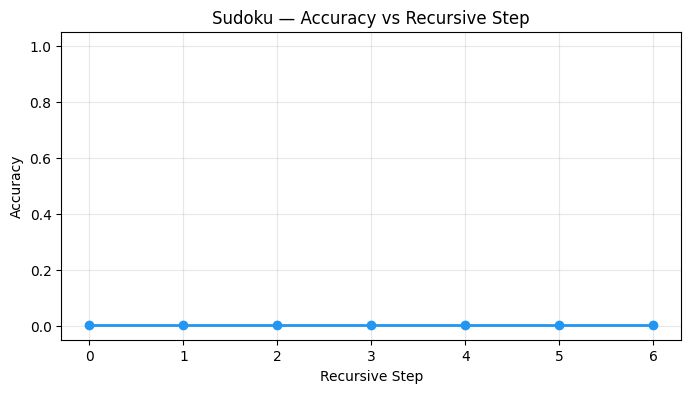

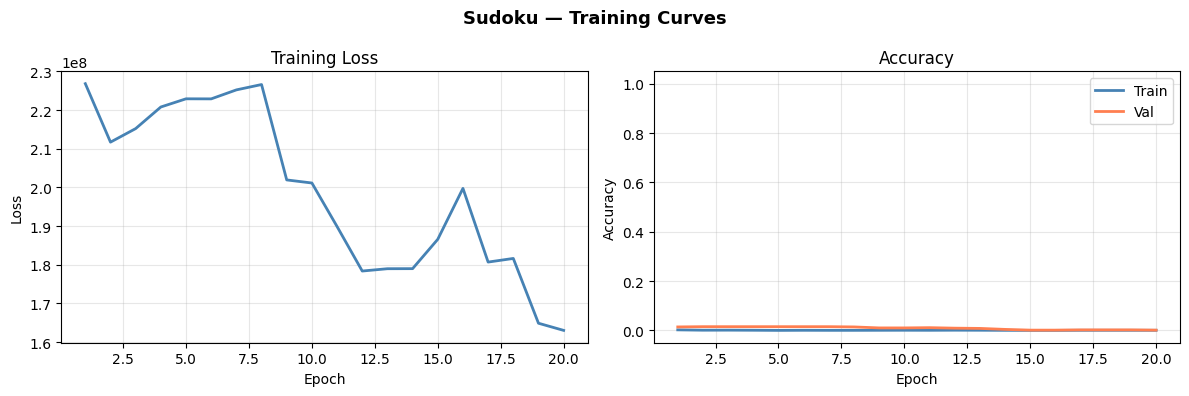

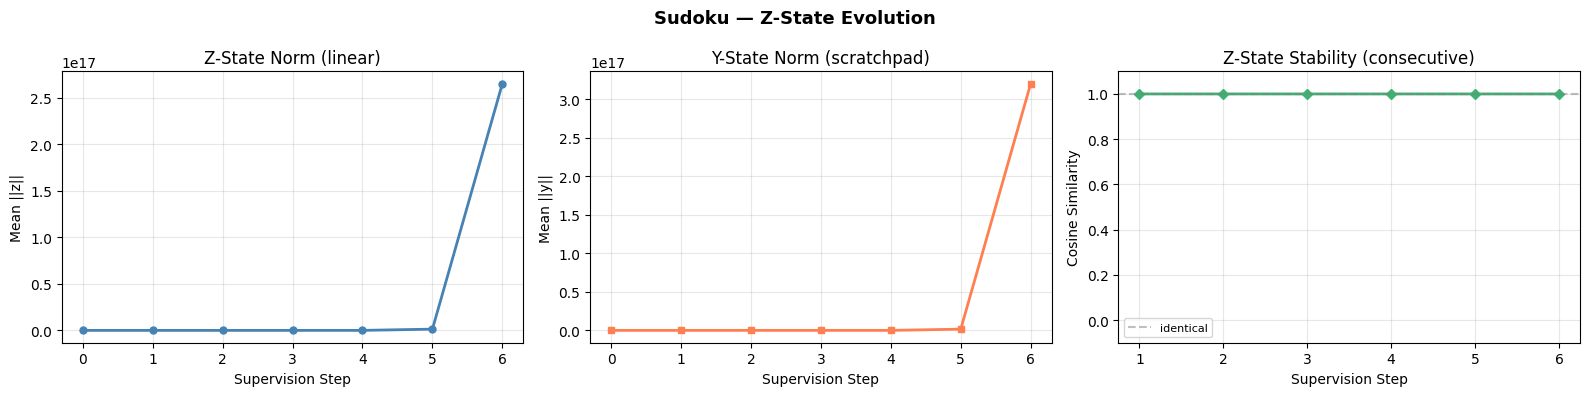

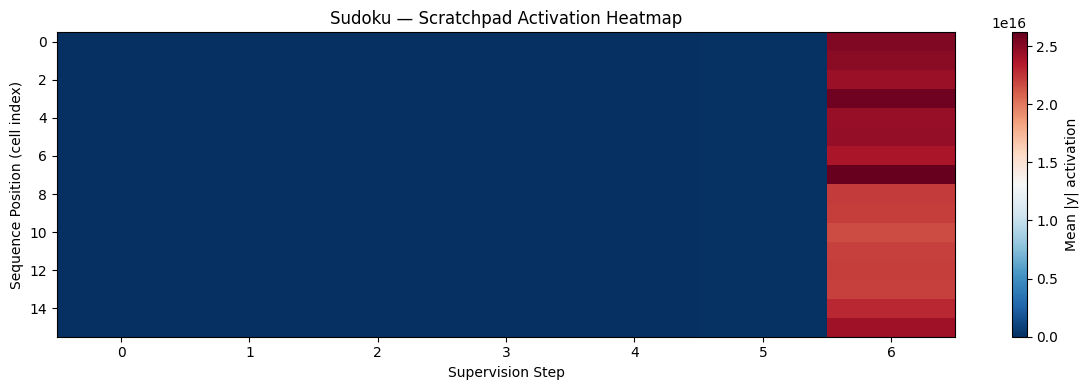

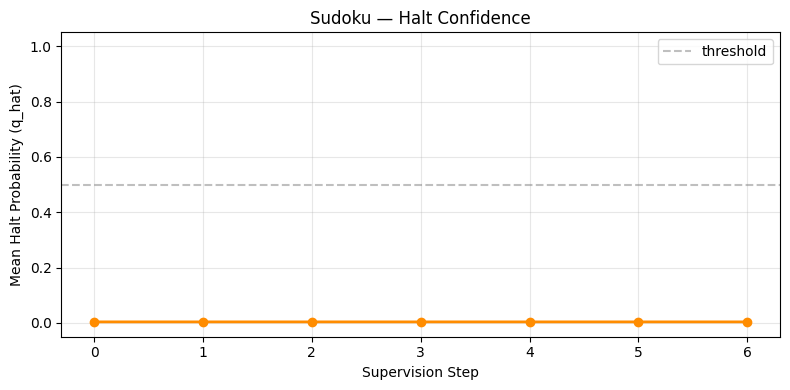


5 files saved to /content/results/
  sudoku_20260404_185547_halt_confidence.png
  sudoku_20260404_185547_per_step.png
  sudoku_20260404_185547_scratchpad.png
  sudoku_20260404_185547_training_curves.png
  sudoku_20260404_185547_z_state.png


In [8]:
#@title 📈 Plots

import matplotlib
import matplotlib.pyplot as plt

# --- 1. Per-step accuracy ---
fig, ax = plt.subplots(figsize=(8, 4))
steps_list = sorted(step_acc.keys())
ax.plot(steps_list, [step_acc[s] for s in steps_list], 'o-', color='#2196F3', linewidth=2, markersize=6)
ax.set_xlabel('Recursive Step'); ax.set_ylabel('Accuracy')
ax.set_title(f'{task.title()} \u2014 Accuracy vs Recursive Step')
ax.set_ylim(-0.05, 1.05); ax.grid(True, alpha=0.3)
fig.savefig(os.path.join(RESULTS_DIR, f'{run_name}_per_step.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# --- 2. Training curves ---
epochs_list = list(range(1, len(epoch_history['loss'])+1))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_list, epoch_history['loss'], '-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)
axes[1].plot(epochs_list, epoch_history['accuracy'], '-', color='steelblue', linewidth=2, label='Train')
if epoch_history['val_accuracy']:
    axes[1].plot(epochs_list[:len(epoch_history['val_accuracy'])], epoch_history['val_accuracy'], '-', color='coral', linewidth=2, label='Val')
    axes[1].legend()
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy')
axes[1].set_ylim(-0.05, 1.05); axes[1].grid(True, alpha=0.3)
fig.suptitle(f'{task.title()} \u2014 Training Curves', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, f'{run_name}_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# --- 3. Z-state evolution ---
z_norms = diagnostics['z_norms']
y_norms = diagnostics['y_norms']
z_cosines = diagnostics.get('z_cosines', [])
d_steps = list(range(len(z_norms)))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(d_steps, z_norms, 'o-', color='steelblue', linewidth=2, markersize=5)
axes[0].set_xlabel('Supervision Step'); axes[0].set_ylabel('Mean ||z||'); axes[0].set_title('Z-State Norm (linear)')
axes[0].grid(True, alpha=0.3)
axes[1].plot(d_steps, y_norms, 's-', color='coral', linewidth=2, markersize=5)
axes[1].set_xlabel('Supervision Step'); axes[1].set_ylabel('Mean ||y||'); axes[1].set_title('Y-State Norm (scratchpad)')
axes[1].grid(True, alpha=0.3)
if z_cosines:
    cos_steps = list(range(1, len(z_cosines)+1))
    axes[2].plot(cos_steps, z_cosines, 'D-', color='mediumseagreen', linewidth=2, markersize=5)
    axes[2].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='identical')
    axes[2].set_ylim(-0.1, 1.1); axes[2].legend(fontsize=8)
axes[2].set_xlabel('Supervision Step'); axes[2].set_ylabel('Cosine Similarity'); axes[2].set_title('Z-State Stability (consecutive)')
axes[2].grid(True, alpha=0.3)
fig.suptitle(f'{task.title()} \u2014 Z-State Evolution', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, f'{run_name}_z_state.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# --- 4. Scratchpad heatmap ---
heatmap = np.stack(diagnostics['y_heatmaps'])
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heatmap.T, aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_xlabel('Supervision Step'); ax.set_ylabel('Sequence Position (cell index)')
ax.set_title(f'{task.title()} \u2014 Scratchpad Activation Heatmap')
fig.colorbar(im, ax=ax, label='Mean |y| activation')
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, f'{run_name}_scratchpad.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# --- 5. Halt confidence ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(d_steps, diagnostics['halt_probs'], 'o-', color='darkorange', linewidth=2, markersize=6)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='threshold')
ax.set_xlabel('Supervision Step'); ax.set_ylabel('Mean Halt Probability (q_hat)')
ax.set_title(f'{task.title()} \u2014 Halt Confidence')
ax.set_ylim(-0.05, 1.05); ax.legend(); ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, f'{run_name}_halt_confidence.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close(fig)

# --- Manifest ---
output_files = [f for f in os.listdir(RESULTS_DIR) if f.startswith(run_name)]
print(f"\n{len(output_files)} files saved to {RESULTS_DIR}/")
for f in sorted(output_files):
    print(f"  {f}")

In [9]:
#@title 💾 Save Results JSON

experiment = {
    'config': cfg,
    'training': {
        'total_steps': step,
        'best_val_acc': best_val_acc,
        'training_time_sec': round(train_time, 1),
        'epoch_losses': [round(v, 6) for v in epoch_history['loss']],
        'epoch_accs': [round(v, 6) for v in epoch_history['accuracy']],
        'val_accs': [round(v, 6) for v in epoch_history['val_accuracy']],
    },
    'per_step_accuracy': {str(k): round(v, 6) for k, v in step_acc.items()},
    'diagnostics': {
        'z_norms': [round(v, 6) for v in diagnostics['z_norms']],
        'y_norms': [round(v, 6) for v in diagnostics['y_norms']],
        'z_cosines': [round(v, 6) for v in diagnostics['z_cosines']],
        'halt_probs': [round(v, 6) for v in diagnostics['halt_probs']],
    },
    'evaluation': {k: round(v, 6) for k, v in detailed.items()},
    'notes': run_notes,
    'timestamp': time.strftime('%Y-%m-%d %H:%M:%S'),
}

results_path = os.path.join(RESULTS_DIR, f'{run_name}_results.json')
with open(results_path, 'w') as f:
    json.dump(experiment, f, indent=2)

print(f"Results saved to {results_path}")
print(f"\n--- Summary ---")
print(f"Cell accuracy:     {detailed['cell_accuracy']:.4f}")
print(f"Puzzle accuracy:   {detailed['puzzle_accuracy']:.4f}")
print(f"Constraint sat:    {detailed['constraint_satisfaction_rate']:.4f}")
print(f"Training time:     {train_time:.0f}s")
print(f"Total steps:       {step}")
print(f"Final z-norm:      {diagnostics['z_norms'][-1]:.2e}")

# --- Full manifest ---
all_outputs = sorted(f for f in os.listdir(RESULTS_DIR) if f.startswith(run_name))
print(f"\n--- All outputs ({len(all_outputs)} files) ---")
for f in all_outputs:
    size = os.path.getsize(os.path.join(RESULTS_DIR, f))
    print(f"  {f}  ({size/1024:.1f} KB)")

Results saved to /content/results/sudoku_20260404_185547_results.json

--- Summary ---
Cell accuracy:     0.4672
Puzzle accuracy:   0.0010
Constraint sat:    0.0010
Training time:     538s
Total steps:       1580
Final z-norm:      2.65e+17

--- All outputs (6 files) ---
  sudoku_20260404_185547_halt_confidence.png  (32.6 KB)
  sudoku_20260404_185547_per_step.png  (27.5 KB)
  sudoku_20260404_185547_results.json  (2.6 KB)
  sudoku_20260404_185547_scratchpad.png  (45.3 KB)
  sudoku_20260404_185547_training_curves.png  (62.8 KB)
  sudoku_20260404_185547_z_state.png  (74.6 KB)


In [10]:
#@title 📥 Download Results (Colab)

run_files = sorted(f for f in os.listdir(RESULTS_DIR) if f.startswith(run_name))
print(f"{len(run_files)} files in {RESULTS_DIR}/:")
for f in run_files:
    print(f"  {f}")

try:
    from google.colab import files
    for f in run_files:
        files.download(os.path.join(RESULTS_DIR, f))
    print("\nAll downloads triggered.")
except ImportError:
    print(f"\nNot on Colab — files are in {os.path.abspath(RESULTS_DIR)}/")

6 files in /content/results/:
  sudoku_20260404_185547_halt_confidence.png
  sudoku_20260404_185547_per_step.png
  sudoku_20260404_185547_results.json
  sudoku_20260404_185547_scratchpad.png
  sudoku_20260404_185547_training_curves.png
  sudoku_20260404_185547_z_state.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All downloads triggered.
